Results:
Lift: 7.17%
P-Value: 0.0000


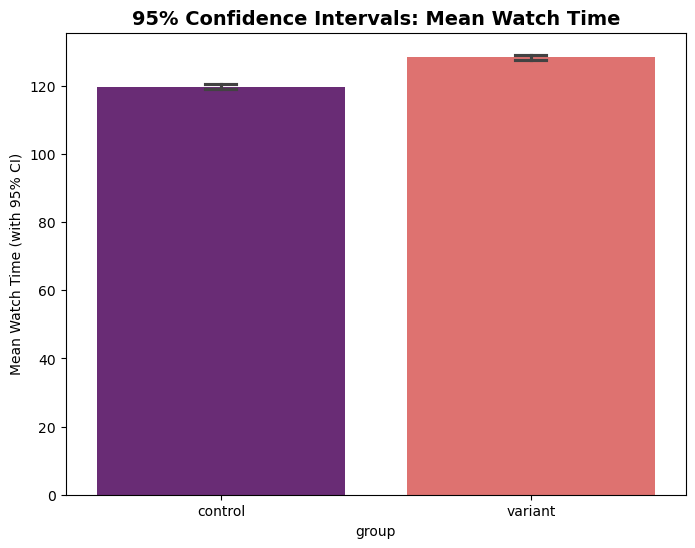

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Loading Data 
data = pd.read_csv('data/raw_engagement_data.csv')

# 2. Statistical Analysis
control_group = data[data['group'] == 'control']['watch_time']
variant_group = data[data['group'] == 'variant']['watch_time']

mean_c, mean_v = control_group.mean(), variant_group.mean()
lift = (mean_v - mean_c) / mean_c
t_stat, p_val = stats.ttest_ind(control_group, variant_group)

print(f"Results:\nLift: {lift:.2%}\nP-Value: {p_val:.4f}")

# 3. Confidence Interval Visualization
plt.figure(figsize=(8, 6))
sns.barplot(
    x='group', 
    y='watch_time', 
    data=data, 
    errorbar=('ci', 95), 
    palette='magma', 
    hue='group', 
    legend=False,
    capsize=.1
)
plt.title('95% Confidence Intervals: Mean Watch Time', fontsize=14, fontweight='bold')
plt.ylabel('Mean Watch Time (with 95% CI)')

# Saving visual
plt.savefig('visuals/confidence_intervals_bar.png', dpi=300, bbox_inches='tight')
plt.show()